# SVM Regression
...depends on activity_threshold

In [1]:
## load data
import pandas as pd

df_pos = pd.read_csv('../../data/inputs/descriptors_positive_staphylococcus.csv')
# df_neg_01 = pd.read_csv('../../data/inputs/descriptors_negative_01_dataset.csv')
df_neg = pd.read_csv('../../data/inputs/descriptors_negative_02_dataset.csv')
# df_neg_03 = pd.read_csv('../../data/inputs/descriptors_negative_03_dataset.csv')

# concat
df = pd.concat([df_pos, df_neg])

In [2]:
# split data
from sklearn.model_selection import train_test_split
from data_cleaner import preprocess_features

X = df.drop(['SEQUENCE', 'ACTIVITY'], axis=1)
y = df['ACTIVITY']
X = preprocess_features(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

-----Variance treshold-----
Features dropped: Index([], dtype='object')
New shape: (884, 102)

-----Correlation filter-----
Features dropped: ['PP1', 'F2', 'F3', 'F4', 'KF1', 'KF2', 'KF4', 'MSWHIM1', 'MSWHIM3', 'E1', 'E2', 'E5', 'PD1', 'PD2', 'PRIN1', 'PRIN2', 'ProtFP1', 'ProtFP2', 'SV2', 'SV3', 'ST1', 'ST6', 'SVGER1', 'SVGER7', 'SVGER10', 'T1', 'T4', 'T5', 'VHSE1', 'VHSE2', 'VHSE3', 'VHSE5', 'VSTPV1', 'VSTPV2', 'VSTPV3', 'Z1', 'Z2', 'Z4']
New shape: (884, 64)


## SVM

In [3]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

# Set the parameters by cross-validation
tuned_parameters = [{'kernel': ['rbf'], 'gamma': [1e-3, 1e-4], 'C': [1, 10, 100, 1000]} ]

# grid search
rgs = GridSearchCV(SVR(), tuned_parameters, cv=5)
rgs.fit(X_train, y_train)

print("Best parameters set found on development set:")

print(rgs.best_params_)

print("Grid scores on development set:")
means = rgs.cv_results_['mean_test_score']
stds = rgs.cv_results_['std_test_score']
for mean, std, params in zip(means, stds, rgs.cv_results_['params']):
    print("%0.3f (+/-%0.03f) for %r"
          % (mean, std * 2, params))

Best parameters set found on development set:
{'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}
Grid scores on development set:
-1.103 (+/-0.261) for {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}
-1.103 (+/-0.261) for {'C': 1, 'gamma': 0.0001, 'kernel': 'rbf'}
-1.101 (+/-0.262) for {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
-1.103 (+/-0.261) for {'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}
-1.083 (+/-0.269) for {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
-1.101 (+/-0.262) for {'C': 100, 'gamma': 0.0001, 'kernel': 'rbf'}
-0.896 (+/-0.270) for {'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}
-1.083 (+/-0.269) for {'C': 1000, 'gamma': 0.0001, 'kernel': 'rbf'}


Accuracy: 0.8531073446327684
Precision: 0.7959183673469388
Recall: 0.9285714285714286
AUC: 0.8567588325652842


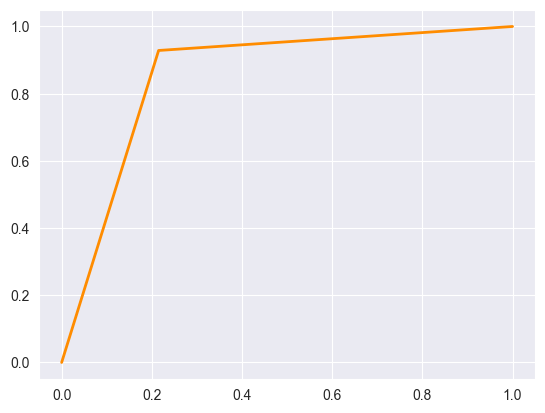

In [4]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

activity_threshold = 9400

model = rgs.best_estimator_
y_pred = model.predict(X_test)
y_pred_binary = y_pred > activity_threshold
y_test_binary = y_test > activity_threshold
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_binary)}")
print(f"Precision: {precision_score(y_test_binary, y_pred_binary)}")
print(f"Recall: {recall_score(y_test_binary, y_pred_binary)}")
print(f"AUC: {roc_auc_score(y_test_binary, y_pred_binary)}")
# plot ROC
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_binary)
roc_auc = auc(fpr, tpr)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)

## Histogram - visualization of y_pred and y_test

In [5]:
y_test.describe()

count      177.000000
mean      4753.801664
std       5000.048277
min          0.500000
25%          9.960000
50%         50.000000
75%      10000.000000
max      10000.000000
Name: ACTIVITY, dtype: float64

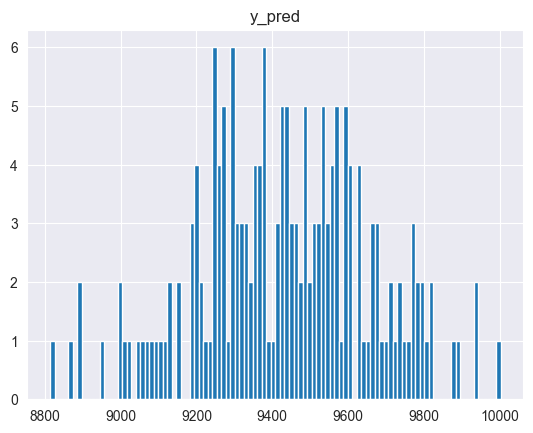

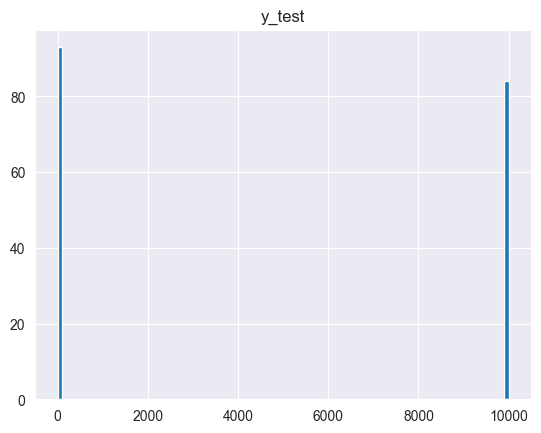

In [6]:
#hist y_pred, y_test
plt.hist(y_pred, bins=100)
plt.title('y_pred')
plt.show()
plt.hist(y_test, bins=100)
plt.title('y_test')
plt.show()

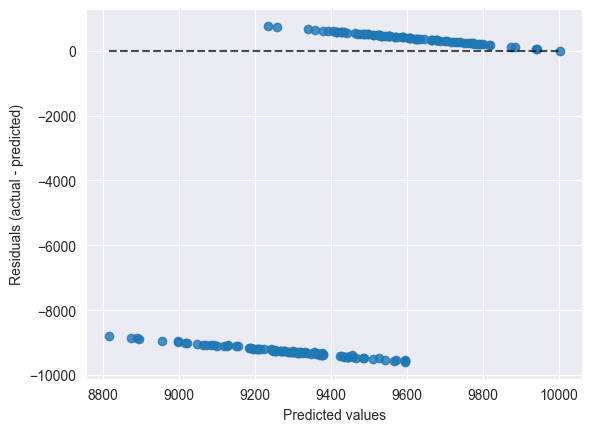

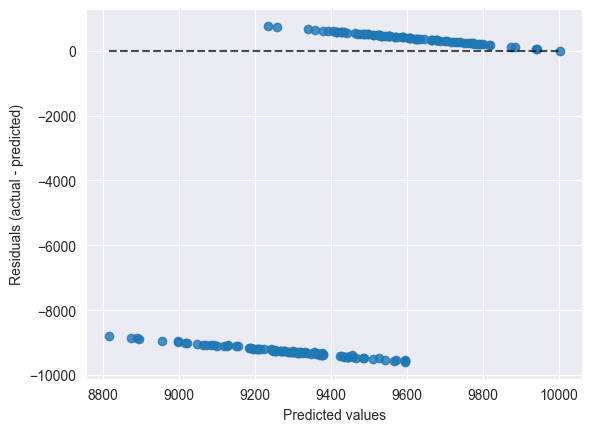

In [7]:
from sklearn.metrics import PredictionErrorDisplay
import matplotlib.pyplot as plt

disp = PredictionErrorDisplay.from_estimator(model, X_test, y_test)
disp.plot()
plt.show()

# nemám tušení co to dělá
